In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import packages and modules
import numpy as np
import sympy as sym
from RL4CRN_Feedback.Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction

In [3]:
# Construct the template CRN
species_labels = ['X_1', 'Z_1', 'Z_2']
inputs_labels = ['u_1', 'u_2']
parameters_labels = ['1', '1', 'alpha', 'eta', 'k']
stoichiometry_reactants = np.array([[0, 1], [0, 0], [0, 0]], dtype=np.int8)
stoichiometry_products = np.array([[0, 0], [1, 0], [0, 0]], dtype=np.int8)
parameters = np.array([1, 1], dtype=np.float32)
input_influence_matrix = np.array([[1, 0], [0, 1]], dtype=np.int8)
outputs = np.array([1], dtype=np.int8)
IOCRN_template = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters, input_influence_matrix, outputs, species_labels, inputs_labels)

# Add reactions
IOCRN_0 = IOCRN_template.clone()
alpha = 1.48; eta = 2.72; k = 1.75
IOCRN_0.add_reaction({'reactant1 index': 1, 'reactant2 index': 3, 'product1 index': 3, 'product2 index': 3, 'input influence index': 0, 'rate constant': alpha}, mode='species index')
IOCRN_0.add_reaction({'reactant1 index': 2, 'reactant2 index': 3, 'product1 index': 1, 'product2 index': 2, 'input influence index': 0, 'rate constant': eta}, mode='species index')
IOCRN_0.add_reaction({'reactant1 index': 0, 'reactant2 index': 2, 'product1 index': 1, 'product2 index': 3, 'input influence index': 0, 'rate constant': k}, mode='species index')
IOCRN_0.print_reactions()

Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2'] 
Output Species: ['X_1'] 
Reaction 0: 0 -> Z_1 ; Rate Constant: 1.0u_1 
Reaction 1: X_1 -> 0 ; Rate Constant: 1.0u_2 
Reaction 2: X_1 + Z_2 -> 2 Z_2 ; Rate Constant: 1.48 
Reaction 3: Z_1 + Z_2 -> X_1 + Z_1 ; Rate Constant: 2.72 
Reaction 4: Z_1 -> X_1 + Z_2 ; Rate Constant: 1.75 



In [4]:
# Print the ODEs
species_symbols = [sym.Symbol('x_1'), sym.Symbol('z_1'), sym.Symbol('z_2')]
inputs_symbols = [sym.Symbol('u_1'), sym.Symbol('u_2')]
parameters_symbols = [sym.Symbol('1'), sym.Symbol('1'), sym.Symbol('alpha'), sym.Symbol('eta'), sym.Symbol('k')]
IOCRN_0.print_ODEs(species_symbols, parameters_symbols, inputs_symbols)

⎡-1⋅u₂⋅x₁ - α⋅x₁⋅z₂ + η⋅z₁⋅z₂ + k⋅z₁⎤
⎢                                   ⎥
⎢            1⋅u₁ - k⋅z₁            ⎥
⎢                                   ⎥
⎣     α⋅x₁⋅z₂ - η⋅z₁⋅z₂ + k⋅z₁      ⎦


Matrix([
[-1*u_2*x_1 - alpha*x_1*z_2 + eta*z_1*z_2 + k*z_1],
[                                   1*u_1 - k*z_1],
[             alpha*x_1*z_2 - eta*z_1*z_2 + k*z_1]])

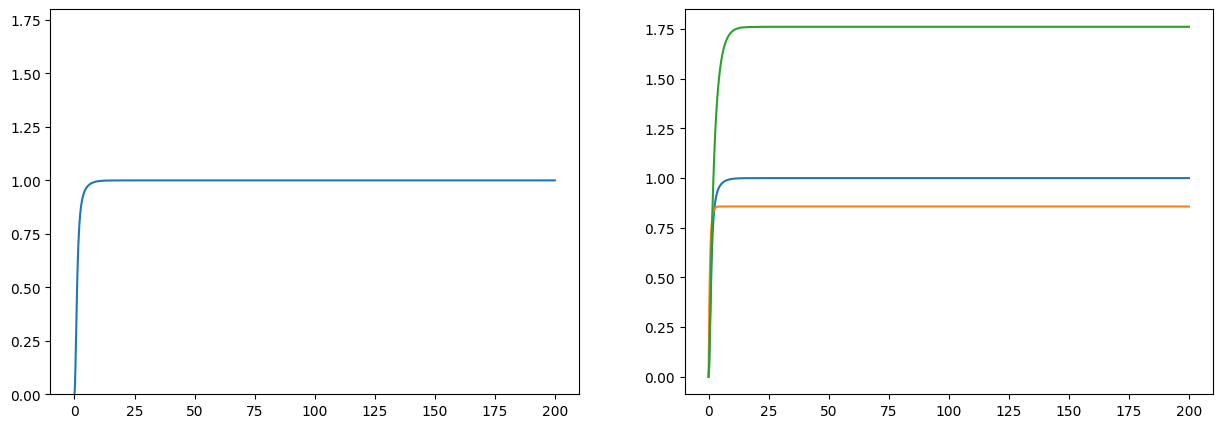

In [33]:
# Simulate
import matplotlib.pyplot as plt
u_1 = 1.5; u_2 = 3; u = np.array([[u_1, u_2]], dtype=np.float32)
initial_condition = np.array([0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, 200, 1000, dtype=np.float32)
y, x = IOCRN_0.transient_response(u, initial_condition, time_horizon, return_states=True)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(time_horizon, y[0])
ax[0].set_ylim(0, 1.8)
ax[0].set_yticks(np.arange(0, 2, 0.25))
ax[1].plot(time_horizon, x)
# ax[1].set_ylim(0, 1.8)
ax[1].set_yticks(np.arange(0, 2, 0.25))
plt.show()
